# First Step

In [1]:
import pandas as pd

path = 'C:/Users/Hychiro/Documents/Mestrado/Mestrado/Mestrado/Review/SLR-BCI-temporal-filters/structured_data/firstStepOutput.csv'

dfFirstStep = pd.read_csv(path)

print(dfFirstStep.head())

                                Autores  \
0  Wang L, Xu G, Wang J, Yang S, Yan W.   
1                Shin J, Kwon J, Im CH.   
2                  Song Y, Sepulveda F.   
3                           D J, K C S.   
4          Jaipriya D, Sriharipriya KC.   

                                              Titulo  Ano de Publicacao  \
0  Application of Hilbert-Huang transform for the...               2008   
1  A Ternary Hybrid EEG-NIRS Brain-Computer Inter...               2018   
2  A novel onset detection technique for brain-co...               2017   
3  Parallel convolutional neural network and empi...               2025   
4  A comparative analysis of masking empirical mo...               2022   

    Fonte  Status     EEG     BCI       MI Classification Model/pipeline  \
0  PubMed  passou  passou  passou   passou         passou         passou   
1  PubMed  passou  passou  passou   passou         passou         passou   
2  PubMed  passou  passou  passou  depende        depende     

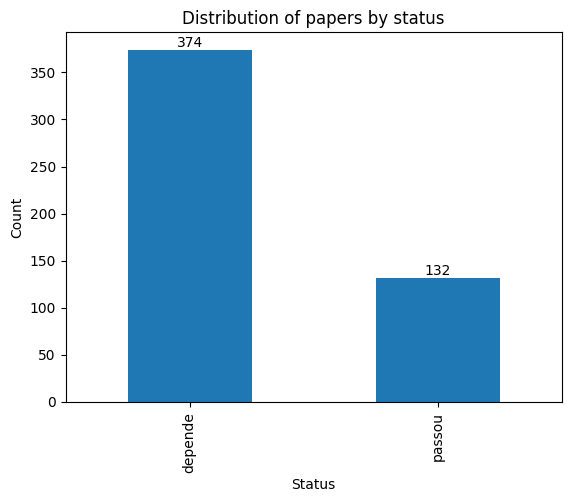

In [2]:
# Dropping papers that do no have passou in status field
dfFirstStepRefined = dfFirstStep[dfFirstStep['Status'] != 'nao_passou']

# visualizing the distribution of the papers by depende or passou in the status field
import matplotlib.pyplot as plt
dfFirstStepRefined['Status'].value_counts().plot(kind='bar')
plt.title('Distribution of papers by status')
plt.xlabel('Status')
plt.ylabel('Count')
# number in bar
plt.bar_label(plt.gca().containers[0])
plt.show()


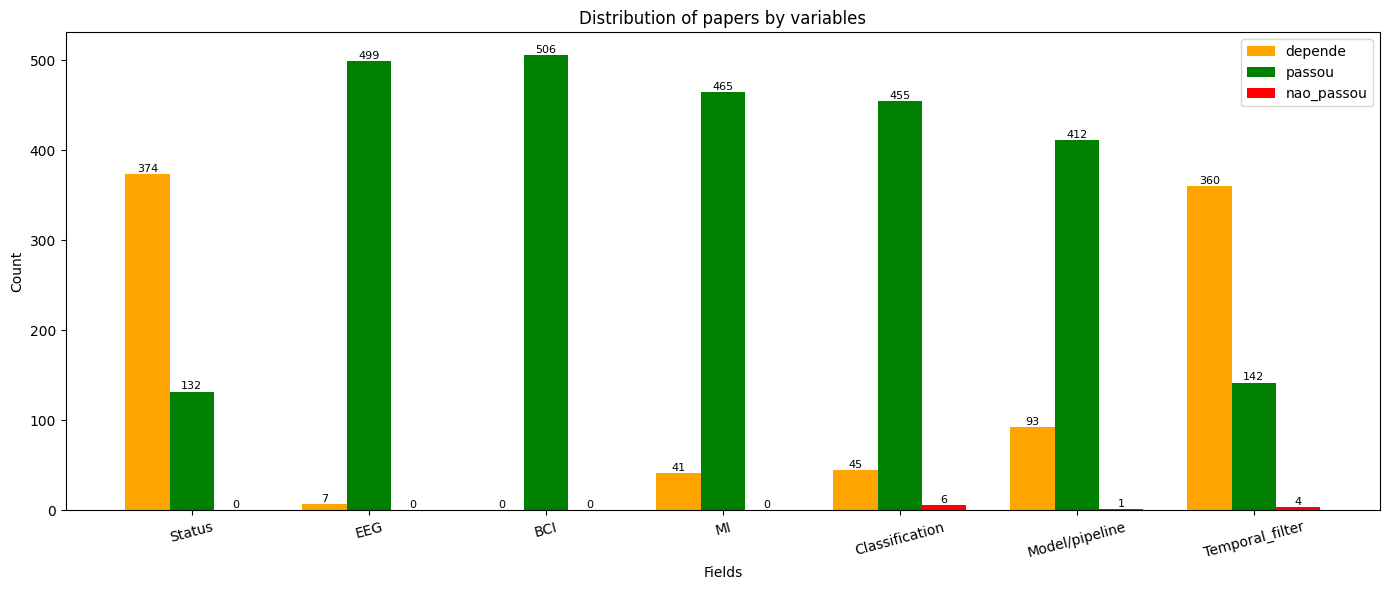

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Resultados
resultStatus = dfFirstStepRefined.groupby('Status').size().to_dict()
resultEEG = dfFirstStepRefined.groupby('EEG').size().to_dict()
resultBCI = dfFirstStepRefined.groupby('BCI').size().to_dict()
resultMI = dfFirstStepRefined.groupby('MI').size().to_dict()
resultClassification = dfFirstStepRefined.groupby('Classification').size().to_dict()
resultModelPipeline = dfFirstStepRefined.groupby('Model/pipeline').size().to_dict()
resultTemporalFilter = dfFirstStepRefined.groupby('Temporal_filter').size().to_dict()

results = [
    resultStatus,
    resultEEG,
    resultBCI,
    resultMI,
    resultClassification,
    resultModelPipeline,
    resultTemporalFilter
]

labels = [
    'Status',
    'EEG',
    'BCI',
    'MI',
    'Classification',
    'Model/pipeline',
    'Temporal_filter'
]

# Categorias
categories = ['depende', 'passou', 'nao_passou']

# Garantir que todas existam
for result in results:
    for cat in categories:
        if cat not in result:
            result[cat] = 0

# Extrai os valores
depende_vals = [r['depende'] for r in results]
passou_vals = [r['passou'] for r in results]
nao_passou_vals = [r['nao_passou'] for r in results]
# Posições no eixo X
x = np.arange(len(labels))

# Largura das barras
width = 0.25

# Cria figura
fig, ax = plt.subplots(figsize=(14, 6))

# Barras lado a lado
bars1 = ax.bar(x - width, depende_vals, width,
               label='depende', color='orange')

bars2 = ax.bar(x, passou_vals, width,
               label='passou', color='green')

bars3 = ax.bar(x + width, nao_passou_vals, width,
               label='nao_passou', color='red')

# Configurações
ax.set_xlabel('Fields')
ax.set_ylabel('Count')
ax.set_title('Distribution of papers by variables')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.legend()

# Valores acima das barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [4]:
# get the annotations of the papers with temporal filter = nao_passou
dfAnalisis = dfFirstStepRefined[dfFirstStepRefined['Temporal_filter'] == 'nao_passou']
dfAnalisis.head()
#print each anotation
for index, row in dfAnalisis.iterrows():
    print(f"Paper {index} named \"{row['Titulo']}\":\n {row['Anotation']}")


Paper 33 named "Rapid prototyping of an EEG-based brain-computer interface (BCI)":
 Fala de "rapid prototyping is possible by using Matlab, Simulink, and the Real-Time Workshop". Não toca no assunto de mostrar um modelo, menos ainda fala de filtro temporal
Paper 34 named "Comparison between covert sound-production task (sound-imagery) vs. motor-imagery for onset detection in real-life online self-paced BCIs":
 Não fala de metodo, fala de uma nova forma de fazer experimentos. Não apresentou nenhum modelo também
Paper 96 named "Study of on-line adaptive discriminant analysis for EEG-based brain computer interfaces":
 Não fala de filtro temporal, nem tenho certeza sobre ser classificação, mas nas keywords fala que é. Verificar o artigo para ver se corta ou não
Paper 108 named "An Adaptive CSP and Clustering Classification for Online Motor Imagery EEG":
 Fala o seguinte "we propose an online and fast generalized eigendecomposition method by Recursive Least Squares updates of the CSP filter

In [6]:
# Sorting data by each field, depende then nao_passou, then passou. Status Columns last to be sorted.
dfSorted = dfFirstStepRefined.sort_values(by=['EEG', 'BCI', 'MI', 'Classification', 'Model/pipeline', 'Temporal_filter', 'Status'], key=lambda x: x.map({'depende': 0, 'nao_passou': 1, 'passou': 2}))
print(dfSorted.head()) 

to_csv_path = 'C:/Users/Hychiro/Documents/Mestrado/Mestrado/Mestrado/Review/SLR-BCI-temporal-filters/structured_data/sortedDataFromFirstStepOutput.csv'
dfSorted.to_csv(to_csv_path, index=False)

                                               Autores  \
289  A. D. Athapattu; P. S. B. Dassanayake; G. S. C...   
514  Z. Wang; C. Cao; Y. Zhou; L. Chen; B. Gu; S. L...   
335  R. Govindarajan; M. Haritha; M. O. Sabri; B. P...   
365         R. Jiang; S. Qiu; Y. Wang; C. Zhang; H. He   
318  Z. Wang; L. Yang; Y. Zhou; L. Chen; B. Gu; S. ...   

                                                Titulo  Ano de Publicacao  \
289  Self-Paced Brain-Computer Interface on Sensori...               2024   
514  Integrating EEG and NIRS improves BCI performa...               2021   
335  Optimal Deep Learning Model and Non-linear Fea...               2025   
365  Evaluation of EEG and MEG responses during Fin...               2024   
318  Incorporating EEG and fNIRS Patterns to Evalua...               2023   

    Fonte   Status      EEG     BCI       MI Classification Model/pipeline  \
289  IEEE  depende  depende  passou  depende         passou         passou   
514  IEEE  depende  depende  pas